# SAAM Project — Part II, Sections 4.1 / 4.2: Net-Zero Portfolio
**Group AT** — North America (AMER) / Scope 1+2

### Section 4.1 — $P^{(vw)}_{oos}(NZ)$: Net-Zero Tracking-Error Portfolio

Same TE-minimization objective as Section 3.3 (otherwise passive investor), with a
carbon reduction constraint that follows a predetermined annual glide path from a
fixed 2013 baseline:

$$\min_{\alpha_Y}\;\sqrt{(\alpha_Y-\alpha_Y^{(vw)})'\Sigma_Y(\alpha_Y-\alpha_Y^{(vw)})}
\quad\text{s.t.}\quad
CF_Y^{(p)} \leq (1-\theta)^{Y-Y_0+1} \times CF^{(vw)}_{Y_0},
\quad\alpha_Y'\mathbf{1}=1,\quad\alpha_{i,Y}\geq 0$$

$\theta=0.10$, $Y_0=2013$. Exponent $Y-Y_0+1$: as stated in the project instructions
(p.8), the first constrained portfolio (Y=2013) already targets a 10% reduction from
the 2013 baseline.

### Section 4.2 — Comparison: $P^{(vw)}$, $P^{(vw)}_{oos}(0.5)$, $P^{(vw)}_{oos}(NZ)$

**Key structural difference between the two constraints:**
- **50% rule (Section 3.3):** target = $0.5\times CF^{(vw)}_Y$ — floats with the current
  VW benchmark each year. Automatically benefits from market-wide decarbonization.
- **Net-Zero (Section 4.1):** target = $(0.9)^{Y-Y_0+1}\times CF^{(vw)}_{Y_0}$ — fixed
  2013 baseline, declines at 10%/yr regardless of what the broad market does.

**Dependencies:** run all previous notebooks before this one.



## 0. Setup and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings, os
warnings.filterwarnings('ignore')

Y0                = 2013
Y_END             = 2024
THETA             = 0.10
ESTIMATION_WINDOW = 120
RIDGE_LAMBDA      = 1e-8
MIN_COMMON_OBS    = 24
DATA_DIR          = './cleaned_data/'
CHARTS_DIR        = './Charts/'
os.makedirs(CHARTS_DIR, exist_ok=True)

COLOR_VW   = '#c0392b'   
COLOR_TE05 = '#e67e22'   
COLOR_NZ   = '#27ae60'   

years_alloc = list(range(Y0, Y_END + 1))
years_p     = years_alloc
print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
required = [
    'returns_monthly.csv', 'co2_total.csv', 'mv_yearly.csv',
    'investment_sets.csv', 'risk_free_rate.csv', 'firm_names.csv',
    'cf_vw_baseline.txt',
    'cf_mv_annual.csv', 'cf_vw_annual.csv',
    'waci_mv_annual.csv', 'waci_vw_annual.csv', 'ci_annual.csv',
    'vw_portfolio_returns.csv', 'mv_portfolio_returns.csv',
    'te05_portfolio_returns.csv', 'carbon_metrics_constrained.csv',
]
missing = [f for f in required if not os.path.exists(f'{DATA_DIR}{f}')]
if missing:
    raise FileNotFoundError(f'Missing: {missing}. Run all previous notebooks first.')

returns_m = pd.read_csv(f'{DATA_DIR}returns_monthly.csv', index_col=0, parse_dates=False)
returns_m.columns = pd.to_datetime(returns_m.columns)
dates_ret   = returns_m.columns.tolist()
dec_ret_idx = {d.year: i for i, d in enumerate(dates_ret) if d.month == 12}

co2_total = pd.read_csv(f'{DATA_DIR}co2_total.csv', index_col=0)
co2_total.columns = [int(c) for c in co2_total.columns]

mv_y = pd.read_csv(f'{DATA_DIR}mv_yearly.csv', index_col=0)
mv_y.columns = [int(c) for c in mv_y.columns]

CI = pd.read_csv(f'{DATA_DIR}ci_annual.csv', index_col=0)
CI.columns = [int(c) for c in CI.columns]

inv_df = pd.read_csv(f'{DATA_DIR}investment_sets.csv')
investment_sets = {int(Y): grp['ISIN'].tolist() for Y, grp in inv_df.groupby('Year')}

rf_df   = pd.read_csv(f'{DATA_DIR}risk_free_rate.csv')
rf_dict = {(int(r['year']), int(r['month'])): r['RF_monthly'] for _, r in rf_df.iterrows()}

firm_names = pd.read_csv(f'{DATA_DIR}firm_names.csv', index_col=0).squeeze().to_dict()

# Net-zero baseline: CF(vw) at Y0=2013, saved as repr(float) for lossless roundtrip
with open(f'{DATA_DIR}cf_vw_baseline.txt') as fh:
    content = fh.read().strip()
# Handle both plain float ('162.39...') and newer NumPy repr ('np.float64(162.39...)')
cf_vw_baseline = float(content.split('(')[-1].rstrip(')'))

def load_annual_series(filename, col):
    s = pd.read_csv(f'{DATA_DIR}{filename}', index_col=0)[col]
    s.index = s.index.astype(int)
    return s.to_dict()

cf_mv   = load_annual_series('cf_mv_annual.csv',   'CF_mv')
cf_vw   = load_annual_series('cf_vw_annual.csv',   'CF_vw')
waci_mv = load_annual_series('waci_mv_annual.csv', 'WACI_mv')
waci_vw = load_annual_series('waci_vw_annual.csv', 'WACI_vw')

df_vw_ret   = pd.read_csv(f'{DATA_DIR}vw_portfolio_returns.csv',   index_col=0, parse_dates=True)
df_mv_ret   = pd.read_csv(f'{DATA_DIR}mv_portfolio_returns.csv',   index_col=0, parse_dates=True)
df_te05_ret = pd.read_csv(f'{DATA_DIR}te05_portfolio_returns.csv', index_col=0, parse_dates=True)

carbon_constrained = pd.read_csv(f'{DATA_DIR}carbon_metrics_constrained.csv', index_col=0)
carbon_constrained.index = carbon_constrained.index.astype(int)
cf_te05   = carbon_constrained['CF_te05'].to_dict()
waci_te05 = carbon_constrained['WACI_te05'].to_dict()

# Net-zero CF targets per year.
# Exponent is Y - Y0 + 1 as per project instructions:
# for Y=Y0=2013 the exponent equals 1, so the first constrained
# portfolio already requires a 10% reduction from the 2013 baseline.
cf_target_nz = {
    Y: (1 - THETA) ** (Y - Y0 + 1) * cf_vw_baseline
    for Y in years_alloc
}

print(f'Net-zero baseline: CF(vw) at Y0={Y0} = {cf_vw_baseline:.4f} t/M$ invested')
print(f'\nNZ targets vs Section 3.3 targets (0.5 x CF(vw)_Y):')
print(f'{"Year":<6} {"NZ target":>11} {"3.3 target":>11} {"NZ tighter?":>12}')
print('-' * 44)
for Y in years_alloc:
    nz  = cf_target_nz[Y]
    te5 = 0.5 * cf_vw[Y]
    print(f'{Y:<6} {nz:>11.3f} {te5:>11.3f} {str(nz < te5):>12}')
print()
print('=> NZ is less tight than the 50% rule in all years: the broad market')
print('   decarbonized ~70% over 2013-2024, while the NZ path requires only')
print('   1 - 0.9^12 ~ 72% cumulative reduction from the 2013 baseline by 2024.')

Net-zero baseline: CF(vw) at Y0=2013 = 162.3932 t/M$ invested

NZ targets vs Section 3.3 targets (0.5 x CF(vw)_Y):
Year     NZ target  3.3 target  NZ tighter?
--------------------------------------------
2013       146.154      81.197        False
2014       131.538      75.751        False
2015       118.385      63.990        False
2016       106.546      69.075        False
2017        95.892      56.485        False
2018        86.302      47.408        False
2019        77.672      47.777        False
2020        69.905      36.345        False
2021        62.914      32.937        False
2022        56.623      26.871        False
2023        50.961      29.108        False
2024        45.865      25.194        False

=> NZ is less tight than the 50% rule in all years: the broad market
   decarbonized ~70% over 2013-2024, while the NZ path requires only
   1 - 0.9^12 ~ 72% cumulative reduction from the 2013 baseline by 2024.


## 2. Helper Functions

In [3]:
def estimate_covariance_robust(ret_window, ridge_lambda=1e-8, min_common_obs=24):
    """Identical to all previous notebooks."""
    N = ret_window.shape[0]
    mu_hat     = ret_window.mean(axis=1).values
    cov_pandas = ret_window.T.cov(min_periods=min_common_obs)
    valid      = (~ret_window.isna()).values.astype(float)
    n_common   = valid @ valid.T
    with np.errstate(divide='ignore', invalid='ignore'):
        adjust = np.where(n_common > 1, (n_common - 1) / n_common, 0.0)
    cov_matrix = cov_pandas.values * adjust
    cov_matrix = np.nan_to_num(cov_matrix, nan=0.0)
    cov_matrix = (cov_matrix + cov_matrix.T) / 2.0
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)
    cov_matrix = (eigvecs * np.maximum(eigvals, 0.0)) @ eigvecs.T
    cov_matrix = (cov_matrix + cov_matrix.T) / 2.0
    cov_matrix += ridge_lambda * np.eye(N)
    return cov_matrix, mu_hat, int((eigvals < -1e-10).sum())


def solve_te_carbon_constrained(cov_matrix, n, w_vw, carbon_coeffs, cf_target, x0):
    """Minimize TE^2 vs VW s.t. CF <= cf_target. Identical to previous notebooks."""
    constraints = [
        {'type': 'eq',   'fun': lambda a: a.sum() - 1.0,               'jac': lambda a: np.ones(n)},
        {'type': 'ineq', 'fun': lambda a: cf_target - carbon_coeffs @ a,'jac': lambda a: -carbon_coeffs},
    ]
    result = minimize(
        lambda a: (a - w_vw) @ cov_matrix @ (a - w_vw),
        x0, method='SLSQP',
        jac=lambda a: 2.0 * cov_matrix @ (a - w_vw),
        bounds=[(0.0, None)] * n, constraints=constraints,
        options={'maxiter': 2000, 'ftol': 1e-9}
    )
    weights = np.maximum(result.x, 0.0)
    weights /= weights.sum()
    te2_monthly = float((weights - w_vw) @ cov_matrix @ (weights - w_vw))
    return weights, np.sqrt(max(te2_monthly, 0.0) * 12), result.success


def find_feasible_seed(carbon_coeffs, w_vw, cf_vw_actual, cf_target):
    """
    Feasible starting point: x0 = (1-t)*w_vw + t*e_{j*} with CF(x0) = cf_target.
    If cf_vw_actual <= cf_target (VW already feasible), t <= 0 -> clipped to 0
    -> x0 = w_vw, which is feasible by construction.
    """
    n      = len(carbon_coeffs)
    j_star = int(np.argmin(carbon_coeffs))
    c_star = carbon_coeffs[j_star]
    denom  = cf_vw_actual - c_star
    if abs(denom) < 1e-12:
        return np.ones(n) / n
    t  = np.clip((cf_vw_actual - cf_target) / denom, 0.0, 1.0)
    e  = np.zeros(n); e[j_star] = 1.0
    x0 = (1 - t) * w_vw + t * e
    x0 = np.maximum(x0, 0.0)
    x0 /= x0.sum()
    return x0


def compute_ex_post_returns(optimal_weights, investment_sets, returns_m,
                             dates_ret, Y0, Y_END):
    """Ex-post monthly returns, T=144. Missing returns filled with 0.0."""
    portfolio_returns = []
    for Y in range(Y0, Y_END + 1):
        w_Y    = optimal_weights[Y]
        isins  = w_Y.index.tolist()
        months = [d for d in dates_ret
                  if d.year == Y + 1 and d <= pd.Timestamp('2025-12-31')]
        if not months: continue
        alpha_t = w_Y.values.copy()
        for dt in months:
            r_stocks = returns_m.loc[isins, dt].fillna(0.0).values
            r_port   = alpha_t @ r_stocks
            portfolio_returns.append({'Date': dt, 'Return': r_port})
            if abs(1 + r_port) > 1e-12:
                alpha_t = alpha_t * (1 + r_stocks) / (1 + r_port)
    df = pd.DataFrame(portfolio_returns).set_index('Date').sort_index()
    assert len(df) == 144, (
        f'Expected 144 months (Jan 2014 - Dec 2025), got {len(df)}. '
        f'First: {df.index[0].strftime("%Y-%m")}, Last: {df.index[-1].strftime("%Y-%m")}.'
    )
    return df


def compute_performance_stats(df_ret, rf_dict, label):
    """Annualized return, vol (ddof=0), Sharpe, CAGR, min, max."""
    r  = df_ret['Return'].values
    rf = np.array([rf_dict.get((dt.year, dt.month), 0.0) for dt in df_ret.index])
    er = r - rf
    return {
        'Portfolio'     : label,
        'Ann. Return'   : np.mean(r) * 12,
        'Ann. Vol.'     : np.std(r, ddof=0) * np.sqrt(12),
        'CAGR'          : np.prod(1 + r) ** (1 / (len(r) / 12)) - 1,
        'Sharpe Ratio'  : np.mean(er) * 12 / (np.std(r, ddof=0) * np.sqrt(12)),
        'Min Monthly'   : r.min(),
        'Max Monthly'   : r.max(),
        'Avg RF (ann.)' : np.mean(rf) * 12,
    }


def compute_carbon_metrics_portfolio(weights_dict, investment_sets,
                                      co2_total, CI, mv_y, years_alloc):
    """WACI and CF. Consistent with carbon_emissions.ipynb."""
    waci, cf = {}, {}
    for Y in years_alloc:
        isins = investment_sets[Y]
        alpha = weights_dict[Y].reindex(isins).fillna(0.0)
        E_Y   = co2_total[Y].reindex(isins)
        CI_Y  = CI[Y].reindex(isins)
        Cap_Y = mv_y[Y].reindex(isins)
        waci_mask = (alpha > 0) & CI_Y.notna()
        waci[Y]   = (alpha[waci_mask] * CI_Y[waci_mask]).sum()
        cf_mask   = (alpha > 0) & E_Y.notna() & Cap_Y.notna() & (Cap_Y > 0)
        cf[Y]     = (alpha[cf_mask] * E_Y[cf_mask] / Cap_Y[cf_mask]).sum()
    return waci, cf


print('Helper functions defined.')

Helper functions defined.


## 3. Pre-computation

 Covariance matrices, VW weights and carbon coefficients re-computed from
 raw data (same estimator as all previous notebooks).

 [Note on cf_vw_actual vs cf_vw[Y] from CSV]
 cf_vw_actual = carbon_coeffs @ w_vw
   = sum_{i: valid E and Cap} (E_i/Cap_i) * (Cap_i/sum_j Cap_j)
   = sum_{i: valid E and Cap} E_i / sum_{j: valid Cap} Cap_j
 This is identical to the formula used in carbon_emissions.ipynb:
   CF_vw[Y] = sum(E[cf_mask]) / total_Cap
 where cf_mask = cap_mask & E.notna() and total_Cap = sum(Cap[cap_mask]).
 The two computations are mathematically equivalent: no discrepancy possible.

In [4]:

precomp_nz = {}

print(f'{"Year":<6} {"N":>5} {"NZ target":>11} {"CF(VW)_act":>12} '
      f'{"min_c":>8} {"t_seed":>8} {"feasible":>9}')
print('-' * 65)

for Y in years_alloc:
    isins = investment_sets[Y]
    n     = len(isins)

    end_idx    = dec_ret_idx[Y]
    start_idx  = end_idx - ESTIMATION_WINDOW + 1
    cov_matrix, _, _ = estimate_covariance_robust(
        returns_m.loc[isins, dates_ret[start_idx:end_idx + 1]],
        RIDGE_LAMBDA, MIN_COMMON_OBS
    )

    E_vals   = co2_total[Y].reindex(isins).values
    Cap_vals = mv_y[Y].reindex(isins).values
    valid_cf = ~np.isnan(E_vals) & ~np.isnan(Cap_vals) & (Cap_vals > 0)
    carbon_coeffs = np.zeros(n)
    carbon_coeffs[valid_cf] = E_vals[valid_cf] / Cap_vals[valid_cf]

    cap_valid = np.where(~np.isnan(Cap_vals) & (Cap_vals > 0), Cap_vals, 0.0)
    total_cap = cap_valid.sum()
    w_vw = cap_valid / total_cap if total_cap > 0 else np.ones(n) / n

    cf_vw_actual = float(carbon_coeffs @ w_vw)
    cf_tgt_nz    = cf_target_nz[Y]
    min_c        = carbon_coeffs.min()
    feasible_nz  = min_c <= cf_tgt_nz

    # t parameter for find_feasible_seed (< 0 means VW already feasible)
    denom  = cf_vw_actual - carbon_coeffs[int(np.argmin(carbon_coeffs))]
    t_seed = (cf_vw_actual - cf_tgt_nz) / denom if abs(denom) > 1e-12 else 0.0

    precomp_nz[Y] = {
        'isins': isins, 'n': n, 'cov_matrix': cov_matrix,
        'carbon_coeffs': carbon_coeffs, 'w_vw': w_vw,
        'cf_vw_actual': cf_vw_actual, 'cf_target_nz': cf_tgt_nz,
    }

    print(f'{Y:<6} {n:>5} {cf_tgt_nz:>11.3f} {cf_vw_actual:>12.3f} '
          f'{min_c:>8.3f} {t_seed:>8.4f} {str(feasible_nz):>9}')

print('\nPre-computation complete.')
print('(t_seed < 0 => VW weights already satisfy NZ constraint for that year)')

Year       N   NZ target   CF(VW)_act    min_c   t_seed  feasible
-----------------------------------------------------------------
2013     337     146.154      162.393    0.208   0.1001      True
2014     348     131.538      151.502    0.145   0.1319      True
2015     364     118.385      127.981    0.055   0.0750      True
2016     381     106.546      138.150    0.110   0.2289      True
2017     400      95.892      112.971    0.005   0.1512      True
2018     436      86.302       94.816    0.004   0.0898      True
2019     503      77.672       95.553    0.004   0.1871      True
2020     532      69.905       72.689    0.002   0.0383      True
2021     560      62.914       65.873    0.002   0.0449      True
2022     570      56.623       53.742    0.002  -0.0536      True
2023     570      50.961       58.217    0.002   0.1246      True
2024     568      45.865       50.389    0.003   0.0898      True

Pre-computation complete.
(t_seed < 0 => VW weights already satisfy NZ cons

---
## Section 4.1 — $P^{(vw)}_{oos}(NZ)$: Net-Zero Portfolio

Same TE-minimization as Section 3.3. CF constraint is the NZ glide path
$(0.9)^{Y-Y_0+1}\times CF^{(vw)}_{Y_0}$ per the project instructions (PDF p.8).

**Starting point strategy:** identical to Section 3.3 — warm-start from previous
year's NZ solution; `find_feasible_seed` for the first year.

In [5]:
nz_weights      = {}
nz_stats        = []
prev_weights_nz = None

print(f'{"Year":<6} {"N":>5} {"N_nz":>6} {"CF_actual":>10} {"CF_target":>10} '
      f'{"CF_ok":>7} {"TE_ann%":>9} {"Conv":>6} {"x0_src":>10}')
print('-' * 78)

for Y in years_alloc:
    pc    = precomp_nz[Y]
    isins = pc['isins']
    n     = pc['n']
    x0_src = ''

    if prev_weights_nz is not None:
        x0 = pd.Series(prev_weights_nz, index=precomp_nz[Y - 1]['isins']) \
               .reindex(isins).fillna(0.0).values
        x0 = x0 / x0.sum() if x0.sum() > 1e-10 else find_feasible_seed(
            pc['carbon_coeffs'], pc['w_vw'],
            pc['cf_vw_actual'], pc['cf_target_nz']
        )
        # Verify warm-start satisfies the NZ constraint after re-alignment
        if float(pc['carbon_coeffs'] @ x0) > pc['cf_target_nz'] * (1 + 1e-6):
            x0 = find_feasible_seed(
                pc['carbon_coeffs'], pc['w_vw'],
                pc['cf_vw_actual'], pc['cf_target_nz']
            )
            x0_src = 'feasible'
        else:
            x0_src = 'warm-start'
    else:
        x0 = find_feasible_seed(
            pc['carbon_coeffs'], pc['w_vw'],
            pc['cf_vw_actual'], pc['cf_target_nz']
        )
        x0_src = 'seed(Y0)'

    weights, te_ann, success = solve_te_carbon_constrained(
        pc['cov_matrix'], n, pc['w_vw'],
        pc['carbon_coeffs'], pc['cf_target_nz'], x0
    )
    if not success:
        print(f'  WARNING Year {Y}: optimizer did not converge.')

    nz_weights[Y]   = pd.Series(weights, index=isins)
    prev_weights_nz = weights.copy()

    cf_actual = float(pc['carbon_coeffs'] @ weights)
    cf_target = pc['cf_target_nz']
    satisfied = cf_actual <= cf_target * (1 + 1e-4)
    if not satisfied:
        print(f'  WARNING Year {Y}: CF violated post-clip ({cf_actual:.4f} > {cf_target:.4f})')

    n_nz = int((weights > 1e-8).sum())
    nz_stats.append({
        'Year': Y, 'N_firms': n, 'N_nonzero': n_nz,
        'Max_weight': weights.max(), 'CF_actual': cf_actual,
        'CF_target': cf_target, 'CF_satisfied': satisfied,
        'TE_ann': te_ann, 'Converged': success,
    })
    print(f'{Y:<6} {n:>5} {n_nz:>6} {cf_actual:>10.4f} {cf_target:>10.4f} '
          f'{str(satisfied):>7} {te_ann*100:>9.3f} {str(success):>6} {x0_src:>10}')

df_nz_stats = pd.DataFrame(nz_stats).set_index('Year')
print(f'\nSummary: {df_nz_stats["Converged"].eq(False).sum()} convergence failures, '
      f'{df_nz_stats["CF_satisfied"].eq(False).sum()} CF violations.')
print(f'Average annualized TE (ex-ante): {df_nz_stats["TE_ann"].mean()*100:.3f}%')

Year       N   N_nz  CF_actual  CF_target   CF_ok   TE_ann%   Conv     x0_src
------------------------------------------------------------------------------
2013     337    303   146.1539   146.1539    True     0.038   True   seed(Y0)
2014     348    302   131.5385   131.5385    True     0.044   True   feasible
2015     364    328   118.3846   118.3846    True     0.037   True warm-start
2016     381    311   100.1138   106.5462    True     0.041   True   feasible
2017     400    346    94.1754    95.8915    True     0.037   True warm-start
2018     436    405    86.3024    86.3024    True     0.038   True   feasible
2019     503    429    77.6722    77.6722    True     0.027   True   feasible
2020     532    500    69.5012    69.9049    True     0.028   True   feasible
2021     560    509    62.9144    62.9144    True     0.026   True   feasible
2022     570    513    51.6301    56.6230    True     0.025   True warm-start
2023     570    503    50.7404    50.9607    True     0.032   T

In [6]:
df_nz_ret = compute_ex_post_returns(
    nz_weights, investment_sets, returns_m, dates_ret, Y0, Y_END
)
print(f'P(vw)_oos(NZ): {len(df_nz_ret)} months | '
      f'{df_nz_ret.index[0].strftime("%Y-%m")} to '
      f'{df_nz_ret.index[-1].strftime("%Y-%m")}')

P(vw)_oos(NZ): 144 months | 2014-01 to 2025-12


In [7]:
stats_vw   = compute_performance_stats(df_vw_ret,   rf_dict, 'P(vw)')
stats_te05 = compute_performance_stats(df_te05_ret, rf_dict, 'P(vw)_oos(0.5)')
stats_nz   = compute_performance_stats(df_nz_ret,   rf_dict, 'P(vw)_oos(NZ)')

# Pre-built lookup dict: used in Section 4.2 trade-off cell to avoid
# redundant compute_performance_stats calls. 
stats_lookup = {
    'P(vw)'         : stats_vw,
    'P(vw)_oos(0.5)': stats_te05,
    'P(vw)_oos(NZ)' : stats_nz,
}

df_stats_41 = pd.DataFrame([stats_vw, stats_nz]).set_index('Portfolio')
print('Performance comparison — Section 4.1: P(vw) vs P(vw)_oos(NZ)')
print('=' * 65)
for col in ['Ann. Return','Ann. Vol.','CAGR','Sharpe Ratio','Min Monthly','Max Monthly']:
    row = f'  {col:<22}'
    for p in df_stats_41.index:
        row += f'  {df_stats_41.loc[p, col]:>12.4f}'
    print(row)
print('\nDifference P(vw)_oos(NZ) - P(vw):')
for col in ['Ann. Return','Ann. Vol.','Sharpe Ratio']:
    diff = df_stats_41.loc['P(vw)_oos(NZ)', col] - df_stats_41.loc['P(vw)', col]
    print(f'  {col:<24} {diff:+.4f}')

Performance comparison — Section 4.1: P(vw) vs P(vw)_oos(NZ)
  Ann. Return                   0.1330        0.1269
  Ann. Vol.                     0.1421        0.1450
  CAGR                          0.1301        0.1227
  Sharpe Ratio                  0.8133        0.7544
  Min Monthly                  -0.1219       -0.1364
  Max Monthly                   0.1269        0.1370

Difference P(vw)_oos(NZ) - P(vw):
  Ann. Return              -0.0062
  Ann. Vol.                +0.0029
  Sharpe Ratio             -0.0589


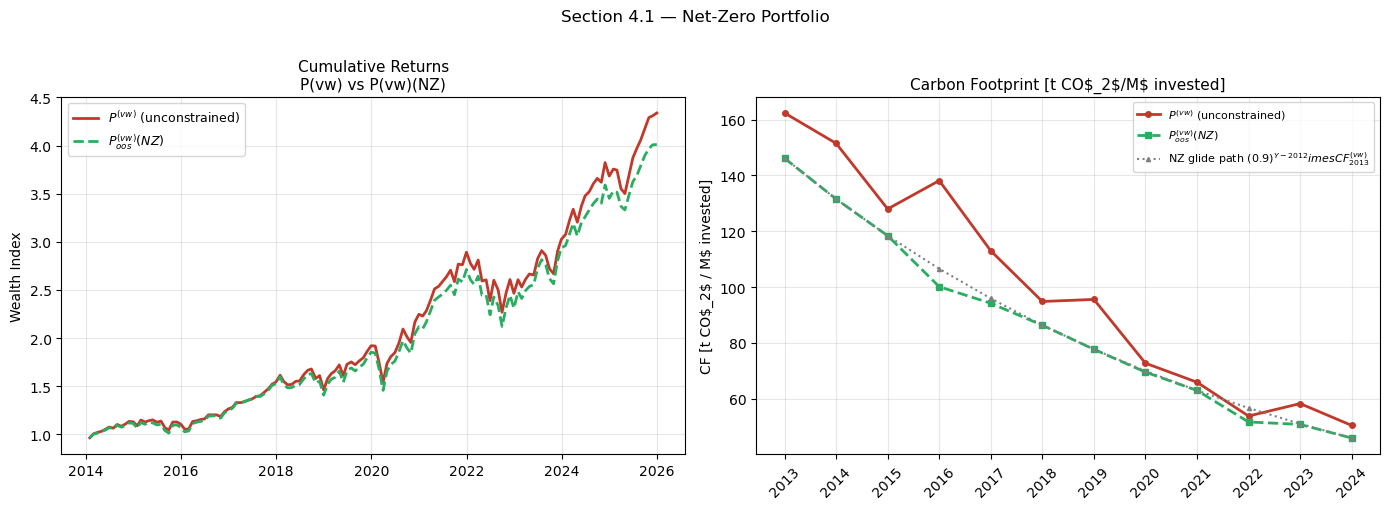

CF vs NZ glide path:
Year      CF(NZ)   NZ target   % of target  Satisfied
-------------------------------------------------------
2013     146.154     146.154        100.0%       True
2014     131.538     131.538        100.0%       True
2015     118.385     118.385        100.0%       True
2016     100.114     106.546         94.0%       True
2017      94.175      95.892         98.2%       True
2018      86.302      86.302        100.0%       True
2019      77.672      77.672        100.0%       True
2020      69.501      69.905         99.4%       True
2021      62.914      62.914        100.0%       True
2022      51.630      56.623         91.2%       True
2023      50.740      50.961         99.6%       True
2024      45.865      45.865        100.0%       True


In [8]:
# cf_nz and waci_nz are computed here (before Section 4.2 uses them)
waci_nz, cf_nz = compute_carbon_metrics_portfolio(
    nz_weights, investment_sets, co2_total, CI, mv_y, years_alloc
)

cum_vw = (1 + df_vw_ret['Return']).cumprod()
cum_nz = (1 + df_nz_ret['Return']).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cum_vw.index, cum_vw.values, color=COLOR_VW, lw=2,
        label=r'$P^{(vw)}$ (unconstrained)')
ax.plot(cum_nz.index, cum_nz.values, color=COLOR_NZ, lw=2, ls='--',
        label=r'$P^{(vw)}_{oos}(NZ)$')
ax.set_title('Cumulative Returns\nP(vw) vs P(vw)(NZ)', fontsize=11)
ax.set_ylabel('Wealth Index')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
nz_targets = [cf_target_nz[Y] for Y in years_p]
ax.plot(years_p, [cf_vw[Y] for Y in years_p], color=COLOR_VW, lw=2, marker='o', ms=4,
        label=r'$P^{(vw)}$ (unconstrained)')
ax.plot(years_p, [cf_nz[Y] for Y in years_p], color=COLOR_NZ, lw=2, marker='s', ms=4,
        ls='--', label=r'$P^{(vw)}_{oos}(NZ)$')
ax.plot(years_p, nz_targets, color='grey', lw=1.5, ls=':', marker='^', ms=3,
        label=r'NZ glide path $(0.9)^{Y-2012}	imes CF^{(vw)}_{2013}$')
ax.set_title(r'Carbon Footprint [t CO$_2$/M$ invested]', fontsize=11)
ax.set_ylabel(r'CF [t CO$_2$ / M$ invested]')
ax.set_xticks(years_p)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle('Section 4.1 — Net-Zero Portfolio', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}sec41_cumret_cf.png', dpi=150, bbox_inches='tight')
plt.show()

print('CF vs NZ glide path:')
print(f'{"Year":<6} {"CF(NZ)":>9} {"NZ target":>11} {"% of target":>13} {"Satisfied":>10}')
print('-' * 55)
for Y in years_alloc:
    pct = cf_nz[Y] / cf_target_nz[Y] * 100
    ok  = cf_nz[Y] <= cf_target_nz[Y] * 1.0001
    print(f'{Y:<6} {cf_nz[Y]:>9.3f} {cf_target_nz[Y]:>11.3f} {pct:>12.1f}% {str(ok):>10}')

---
## Section 4.2 — Comparison: $P^{(vw)}$, $P^{(vw)}_{oos}(0.5)$, $P^{(vw)}_{oos}(NZ)$

We compare the three passive-investor portfolios to assess the trade-off between
financial performance and carbon reduction.

 the 50% rule in Section 3.3 tracks the *current year* VW benchmark,
so the absolute CF target falls automatically as the broad market decarbonizes.
The NZ path uses a *fixed 2013 baseline*, providing a predictable long-run trajectory
but without benefiting from market-wide carbon reduction. Over 2013–2024, the broad market
decarbonized at ~10.7%/year — slightly faster than the 10%/year NZ requirement — making
the NZ constraint less demanding than the 50% rule in absolute terms throughout the sample.

In [9]:
all_passive = pd.DataFrame([stats_vw, stats_te05, stats_nz]).set_index('Portfolio')

display_stats = all_passive[['Ann. Return','Ann. Vol.','CAGR',
                              'Sharpe Ratio','Min Monthly','Max Monthly']].copy()
for c in ['Ann. Return','Ann. Vol.','CAGR','Min Monthly','Max Monthly']:
    display_stats[c] = display_stats[c].map(lambda x: f'{x*100:.2f}%')
display_stats['Sharpe Ratio'] = display_stats['Sharpe Ratio'].map(lambda x: f'{x:.4f}')

print('Performance summary — Section 4.2:')
display(display_stats)

# sorted() ensures year-order aggregation regardless of dict insertion order.
# cf_vw, cf_te05, cf_nz are all indexed by integer year; sorted() makes the order explicit.
cf_mean_vw   = np.mean([cf_vw[Y]   for Y in sorted(cf_vw)])
cf_mean_te05 = np.mean([cf_te05[Y] for Y in sorted(cf_te05)])
cf_mean_nz   = np.mean([cf_nz[Y]   for Y in sorted(cf_nz)])

cf_summary = pd.DataFrame({
    'CF_mean' : {'P(vw)': cf_mean_vw, 'P(vw)_oos(0.5)': cf_mean_te05,
                 'P(vw)_oos(NZ)': cf_mean_nz},
    'CF_2013' : {'P(vw)': cf_vw[2013], 'P(vw)_oos(0.5)': cf_te05[2013],
                 'P(vw)_oos(NZ)': cf_nz[2013]},
    'CF_2024' : {'P(vw)': cf_vw[2024], 'P(vw)_oos(0.5)': cf_te05[2024],
                 'P(vw)_oos(NZ)': cf_nz[2024]},
    'CF_reduc_vs_VW (%)': {
        'P(vw)'         : 0.0,
        'P(vw)_oos(0.5)': (1 - cf_mean_te05 / cf_mean_vw) * 100,
        'P(vw)_oos(NZ)' : (1 - cf_mean_nz   / cf_mean_vw) * 100,
    },
}).T
print('\nCarbon footprint summary:')
display(cf_summary.round(3))

# Ex-post TE stored in a dict — both values accessible after the loop.
# Previously te_ex_post was overwritten at each iteration, leaving only the last value.
te_ex_post = {}
print('\nTracking error vs VW benchmark — ex-post annualized (ddof=0):')
for label, df_p in [('P(vw)_oos(0.5)', df_te05_ret), ('P(vw)_oos(NZ)', df_nz_ret)]:
    r_diff = df_p['Return'].values - df_vw_ret['Return'].values
    te_ex_post[label] = np.std(r_diff, ddof=0) * np.sqrt(12)
    print(f'  {label:<22} TE = {te_ex_post[label]*100:.3f}%')

Performance summary — Section 4.2:


,Ann. Return,Ann. Vol.,CAGR,Sharpe Ratio,Min Monthly,Max Monthly
Portfolio,,,,,,
P(vw),13.30%,14.21%,13.01%,0.8133,-12.19%,12.69%
P(vw)_oos(0.5),12.48%,14.60%,12.03%,0.7356,-13.99%,13.47%
P(vw)_oos(NZ),12.69%,14.50%,12.27%,0.7544,-13.64%,13.70%



Carbon footprint summary:


,P(vw),P(vw)_oos(0.5),P(vw)_oos(NZ)
CF_mean,98.690,49.345,86.249
CF_2013,162.393,81.197,146.154
CF_2024,50.389,25.194,45.865
CF_reduc_vs_VW (%),0.000,50.000,12.606



Tracking error vs VW benchmark — ex-post annualized (ddof=0):
  P(vw)_oos(0.5)         TE = 1.883%
  P(vw)_oos(NZ)          TE = 1.718%


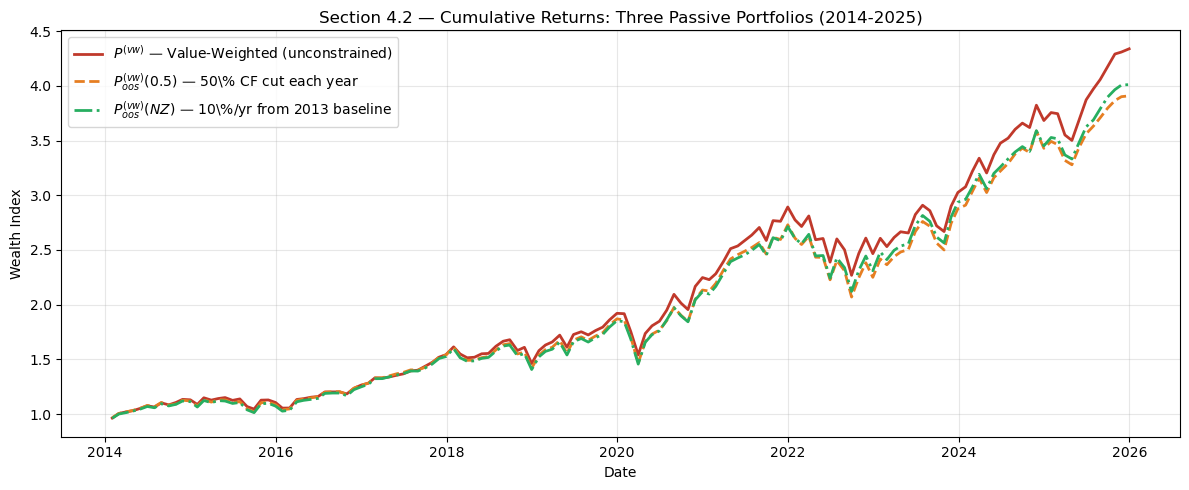

In [10]:
# All cumulative return series redefined here — self-contained cell.
# Previously cum_vw and cum_nz depended on Cell 14 having been run.
cum_vw   = (1 + df_vw_ret['Return']).cumprod()
cum_te05 = (1 + df_te05_ret['Return']).cumprod()
cum_nz   = (1 + df_nz_ret['Return']).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_vw.index,   cum_vw.values,   color=COLOR_VW,   lw=2,
        label=r'$P^{(vw)}$ — Value-Weighted (unconstrained)')
ax.plot(cum_te05.index, cum_te05.values, color=COLOR_TE05, lw=2, ls='--',
        label=r'$P^{(vw)}_{oos}(0.5)$ — 50\% CF cut each year')
ax.plot(cum_nz.index,   cum_nz.values,   color=COLOR_NZ,   lw=2, ls='-.',
        label=r'$P^{(vw)}_{oos}(NZ)$ — 10\%/yr from 2013 baseline')

ax.set_title('Section 4.2 — Cumulative Returns: Three Passive Portfolios (2014-2025)',
             fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Wealth Index')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}sec42_cumret_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

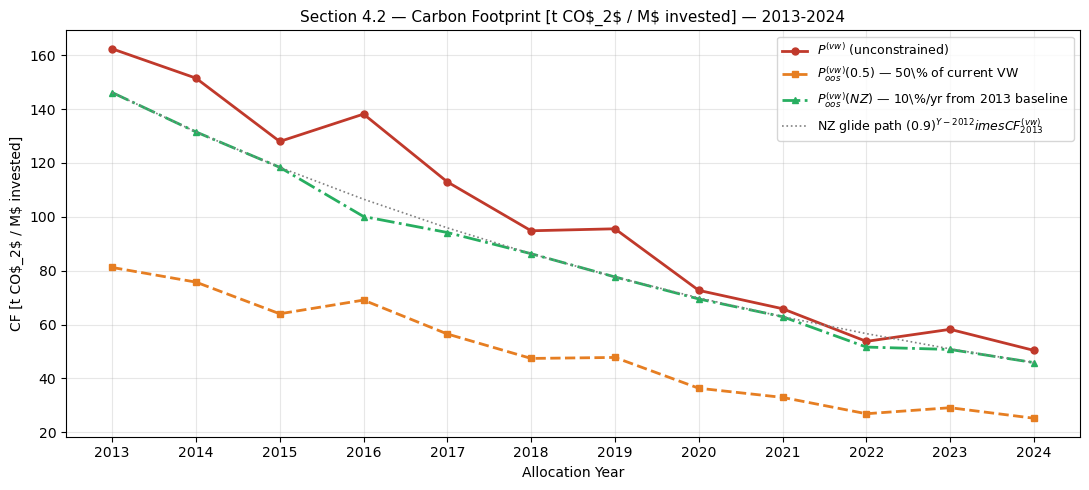

CF levels at start and end of sample:
  Portfolio                   CF 2013   CF 2024   Total reduc.
--------------------------------------------------------------
  P(vw)                        162.39     50.39          69.0%
  P(vw)_oos(0.5)                81.20     25.19          69.0%
  P(vw)_oos(NZ)                146.15     45.86          68.6%


In [11]:
# years_p = years_alloc is in scope from setup. CF dicts accessed by key
# (not iterated for aggregation), so no sorted() needed here.
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(years_p, [cf_vw[Y]   for Y in years_p], color=COLOR_VW,   lw=2, marker='o', ms=5,
        label=r'$P^{(vw)}$ (unconstrained)')
ax.plot(years_p, [cf_te05[Y] for Y in years_p], color=COLOR_TE05, lw=2, marker='s', ms=5,
        ls='--', label=r'$P^{(vw)}_{oos}(0.5)$ — 50\% of current VW')
ax.plot(years_p, [cf_nz[Y]   for Y in years_p], color=COLOR_NZ,   lw=2, marker='^', ms=5,
        ls='-.', label=r'$P^{(vw)}_{oos}(NZ)$ — 10\%/yr from 2013 baseline')
ax.plot(years_p, [cf_target_nz[Y] for Y in years_p], color='grey', lw=1.2, ls=':',
        label=r'NZ glide path $(0.9)^{Y-2012}	imes CF^{(vw)}_{2013}$')

ax.set_title(r'Section 4.2 — Carbon Footprint [t CO$_2$ / M$ invested] — 2013-2024',
             fontsize=11)
ax.set_xlabel('Allocation Year')
ax.set_ylabel(r'CF [t CO$_2$ / M$ invested]')
ax.set_xticks(years_p)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}sec42_cf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('CF levels at start and end of sample:')
print(f'  {"Portfolio":<25} {"CF 2013":>9} {"CF 2024":>9} {"Total reduc.":>14}')
print('-' * 62)
for label, cf_dict in [('P(vw)',cf_vw),('P(vw)_oos(0.5)',cf_te05),('P(vw)_oos(NZ)',cf_nz)]:
    reduc = (1 - cf_dict[2024] / cf_dict[2013]) * 100
    print(f'  {label:<25} {cf_dict[2013]:>9.2f} {cf_dict[2024]:>9.2f} {reduc:>13.1f}%')

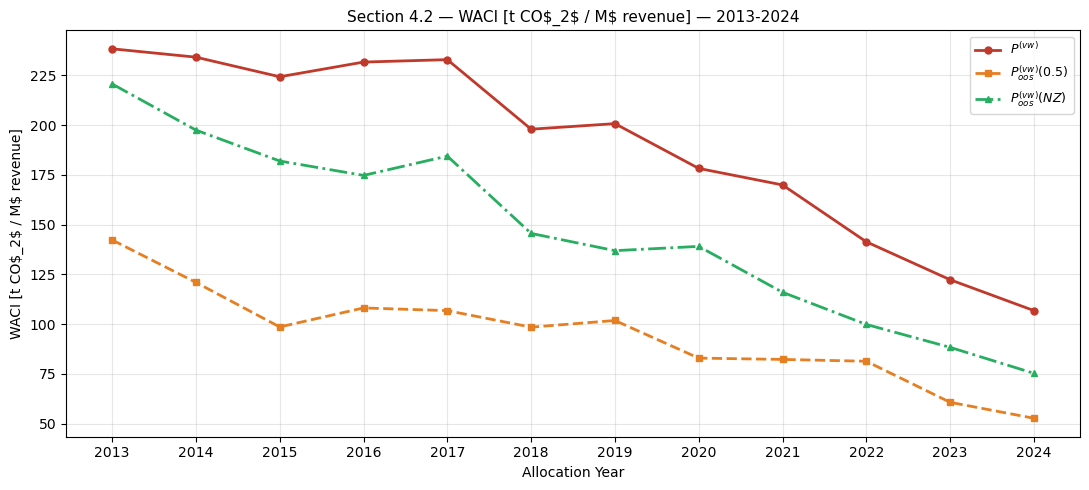

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(years_p, [waci_vw[Y]   for Y in years_p], color=COLOR_VW,   lw=2, marker='o', ms=5,
        label=r'$P^{(vw)}$')
ax.plot(years_p, [waci_te05[Y] for Y in years_p], color=COLOR_TE05, lw=2, marker='s', ms=5,
        ls='--', label=r'$P^{(vw)}_{oos}(0.5)$')
ax.plot(years_p, [waci_nz[Y]   for Y in years_p], color=COLOR_NZ,   lw=2, marker='^', ms=5,
        ls='-.', label=r'$P^{(vw)}_{oos}(NZ)$')
ax.set_title(r'Section 4.2 — WACI [t CO$_2$ / M$ revenue] — 2013-2024', fontsize=11)
ax.set_xlabel('Allocation Year')
ax.set_ylabel(r'WACI [t CO$_2$ / M$ revenue]')
ax.set_xticks(years_p)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}sec42_waci_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# sorted() for safe aggregation.
# cum_ variables redefined in Cell 17 to avoid cross-cell dependency.
# stats_lookup pre-built in Cell 13 — no redundant compute_performance_stats.

print('Trade-off summary — passive investor (all differences relative to P(vw))')
print('=' * 78)
print(f'{"":30} {"Sharpe diff":>13} {"Return diff":>13} '
      f'{"CF reduc.%":>12} {"TE ex-post":>11}')
print('-' * 78)

for label, df_p, cf_dict in [
    ('P(vw)_oos(0.5)', df_te05_ret, cf_te05),
    ('P(vw)_oos(NZ)',  df_nz_ret,   cf_nz),
]:
    # Use pre-built stats instead of recomputing
    s_p    = stats_lookup[label]
    # te_ex_post stored as dict — values available for both portfolios
    te_ep  = te_ex_post[label]
    # sorted() for safe mean computation across years
    cf_red = (1 - np.mean([cf_dict[Y] for Y in sorted(cf_dict)]) /
                  np.mean([cf_vw[Y]   for Y in sorted(cf_vw)])) * 100
    sh_d   = s_p['Sharpe Ratio'] - stats_vw['Sharpe Ratio']
    ret_d  = (s_p['Ann. Return'] - stats_vw['Ann. Return']) * 100

    print(f'{label:<30} {sh_d:>+13.4f} {ret_d:>+12.2f}% '
          f'{cf_red:>11.1f}% {te_ep*100:>10.3f}%')

print()
print('Interpretation:')
print('  P(vw)_oos(NZ) tracks VW more closely (lower TE, smaller financial cost)')
print('  than P(vw)_oos(0.5). The NZ constraint is less tight in absolute terms')
print('  throughout 2013-2024 because the VW market decarbonized at ~10.7%/yr,')
print('  slightly faster than the 10%/yr NZ requirement.')
print()
print('  The 50% rule achieves more aggressive absolute CF reduction because')
print('  it does not credit the portfolio for broad-market decarbonization.')
print('  The NZ path provides a predictable long-run trajectory independent of')
print('  the benchmark, but its required effort in this sample is relatively modest.')

Trade-off summary — passive investor (all differences relative to P(vw))
                                 Sharpe diff   Return diff   CF reduc.%  TE ex-post
------------------------------------------------------------------------------
P(vw)_oos(0.5)                       -0.0777        -0.82%        50.0%      1.883%
P(vw)_oos(NZ)                        -0.0589        -0.62%        12.6%      1.718%

Interpretation:
  P(vw)_oos(NZ) tracks VW more closely (lower TE, smaller financial cost)
  than P(vw)_oos(0.5). The NZ constraint is less tight in absolute terms
  throughout 2013-2024 because the VW market decarbonized at ~10.7%/yr,
  slightly faster than the 10%/yr NZ requirement.

  The 50% rule achieves more aggressive absolute CF reduction because
  it does not credit the portfolio for broad-market decarbonization.
  The NZ path provides a predictable long-run trajectory independent of
  the benchmark, but its required effort in this sample is relatively modest.


## 4. Save Results

In [14]:
df_nz_ret.to_csv(f'{DATA_DIR}nz_portfolio_returns.csv')

def save_weights(wt_dict, filename):
    rows = []
    for Y, w in wt_dict.items():
        for isin, wt in w.items():
            if wt > 1e-10:
                rows.append({'Year': Y, 'ISIN': isin, 'Weight': wt})
    pd.DataFrame(rows).to_csv(f'{DATA_DIR}{filename}', index=False)

save_weights(nz_weights, 'nz_optimal_weights.csv')

pd.DataFrame({'CF_nz': cf_nz, 'WACI_nz': waci_nz}).to_csv(
    f'{DATA_DIR}carbon_metrics_nz.csv'
)
pd.DataFrame([stats_vw, stats_te05, stats_nz]).set_index('Portfolio').to_csv(
    f'{DATA_DIR}summary_stats_sec42.csv'
)
df_nz_stats.to_csv(f'{DATA_DIR}nz_opt_diagnostics.csv')

saved = ['nz_portfolio_returns.csv', 'nz_optimal_weights.csv',
         'carbon_metrics_nz.csv', 'summary_stats_sec42.csv',
         'nz_opt_diagnostics.csv']
print('Saved to cleaned_data/:')
for f in saved:
    kb = os.path.getsize(f'{DATA_DIR}{f}') / 1024
    print(f'  {f:<42} {kb:>7.1f} KB')

print(f'\nCharts saved to {CHARTS_DIR}:')
for f in ['sec41_cumret_cf.png','sec42_cumret_comparison.png',
          'sec42_cf_comparison.png','sec42_waci_comparison.png']:
    if os.path.exists(f'{CHARTS_DIR}{f}'):
        print(f'  {f}')

print('\nPart II complete. All results saved.')

Saved to cleaned_data/:
  nz_portfolio_returns.csv                       4.5 KB
  nz_optimal_weights.csv                       190.9 KB
  carbon_metrics_nz.csv                          0.5 KB
  summary_stats_sec42.csv                        0.5 KB
  nz_opt_diagnostics.csv                         1.3 KB

Charts saved to ./Charts/:
  sec41_cumret_cf.png
  sec42_cumret_comparison.png
  sec42_cf_comparison.png
  sec42_waci_comparison.png

Part II complete. All results saved.
